In [1]:
from importlib import reload
import evosim
reload(evosim); None

---
# Simulations

In [2]:
# Here are all the default arguments.
# Any arguments you add below will override these defaults.

display("default arguments:", evosim.default_args)

'default arguments:'

{'numPops': 1,
 'N': 100000.0,
 'minMu': 2,
 'numClades': 1,
 'aToB': 0.5,
 'T': 1000.0,
 's': 0.1,
 'numEpochs': 1,
 'numRuns': 1,
 'includeMutation': True,
 'stochasticEnv': False,
 'plotLog': False,
 'plotAB': True,
 'plotKFit': False,
 'hideB': False,
 'printStats': False}

---
### Reminder: long-term selection on different mutators in alternating environments


Infinite population size N (there is no drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Note: setting numRuns to 1 because N < 0 (infinite population)


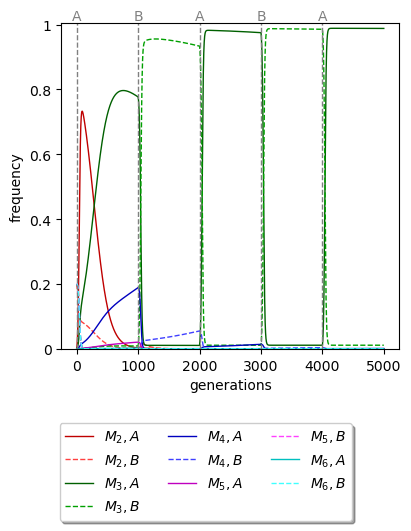

In [3]:
args = evosim.default_args.copy()
args.s = 0.1 # s has to be kept high relative to T, so that sT is not too small
args.aToB = 0.0
args.minMu = 2
args.numClades = 5

###

args.plotAB = True # True, try False to see only mutator clades
args.plotLog = False # False, try True to see longer term dynamics

args.T = 1e3 # 1e3, try 1e2, 1e3, 1e4, 1e5 - notice that M2, M3, M4, M5 win!
args.numEpochs = 5 # 5

args.N = -1 # -1 change this to 1e3, 1e4 to see differential effect of selection vs drift

evosim.evosim(args)

---
### Infinite population case

Infinite population size N (there is no drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Note: setting numRuns to 1 because N < 0 (infinite population)


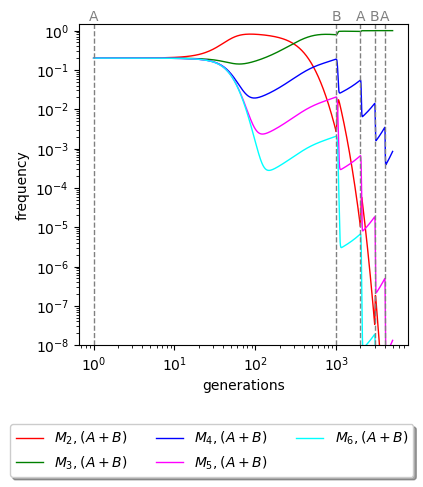

In [4]:
args = evosim.default_args.copy()
args.s = 0.1 # s has to be kept high relative to T, so that sT is not too small
args.aToB = 0.0
args.minMu = 2
args.numClades = 5
args.plotAB = False # False
args.plotLog = True # False

###

args.T = 1e3 # 1e3
args.numEpochs = 5 # 5

args.N = -1 # -1, change to 1e4

evosim.evosim(args)

---
### Finite population case

Ns:1000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))


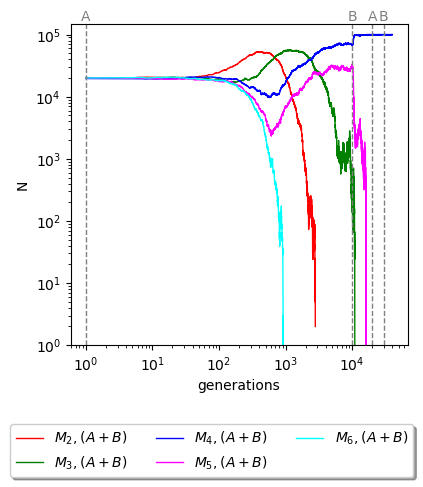

In [ ]:
args = evosim.default_args.copy()
args.plotLog = True
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5
args.plotAB = False

###

args.T = 1e4 # 1e4
args.numEpochs = 4 # 4
args.N = 1e5 # 1e5

args.numRuns = 1 # 1, try multiple runs to average out stochasticity. max of 4 or maybe 8

evosim.evosim(args)

### Plotting k-fitness, k-survivability and k-surprisal !!

Ns:1000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Using 4 processes for 4 runs.


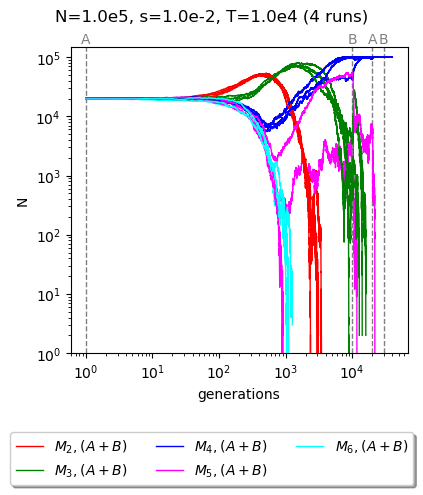

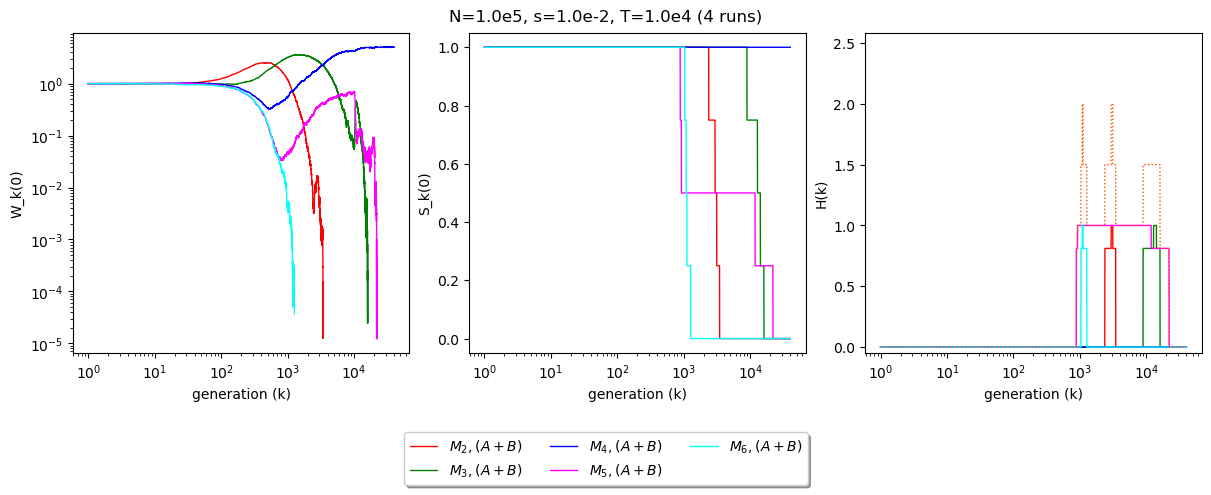

In [ ]:
args = evosim.default_args.copy()
args.plotLog = True
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5
args.plotAB = False

###

args.T = 1e4 # 1e4
args.numEpochs = 4 # 4
args.N = 1e5 # 1e5

args.numRuns = 4 # 4, multiple runs to average out stochasticity. max of 4 or maybe 8
args.plotKFit = True # plot k-fitness, k-survivability

evosim.evosim(args)

### K-fitness

$W_k(t)= mean(\frac{N(t+k)}{N(t)}) \hspace{1cm} (k \ge 1) \hspace{1cm} $ (mean over R replicates)

Usually, we just look at $W_k(0)$: the k-fitness for a clade founded at t=0, plotted with k on the x axis.

<br>

### K-survivability

$S_k(t)= p(N(t+k)) > 0) \hspace{1cm} (k \ge 1)\hspace{1cm} $ (p over R replicates)

Usually, we just look at $S_k(0)$: the k-survivability for a clade founded at t=0, plotted with k on the x axis.

<br>

### Equivalence of k-fitness and k-survivability

If clades could only have 0 or 1 "members", the k-fitness looks like the k-survivability!

$W_k(t)= mean(\frac{N(t+k)}{N(t)}) = mean(\frac{N(t+k)) > 0}{1})= \frac{p(N(t+k)) > 0)}{1} = S_k(t) \hspace{1cm} $ (means and p over R replicates)

<br>

---

### Entropy

With a set of $n$ possible outcomes of probability $p_i$, their "entropy" is:

$H = - \sum_{i=1}^{n} p_i \log p_i$

<br>When there are only 2 cases A and B, there are only 2 probs $p$ and $q$:

$q = 1-p$

$H = - p \log p - q \log q $


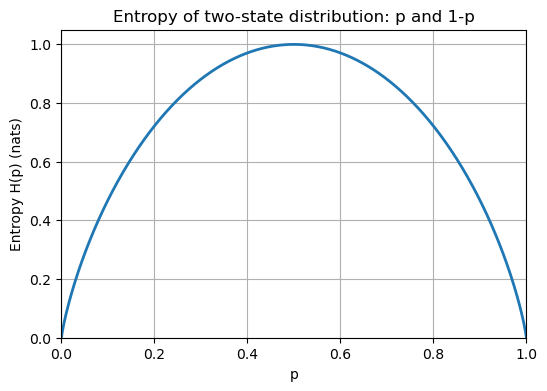

In [11]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.0, 1.0, 500)
eps = 1e-12
p_clip = np.clip(p, eps, 1.0 - eps)
H = -p_clip * np.log2(p_clip) - (1.0 - p_clip) * np.log2(1.0-p_clip)

plt.figure(figsize=(6, 4))
plt.plot(p, H, lw=2)
plt.xlabel('p')
plt.ylabel('Entropy H(p) (nats)')
plt.title('Entropy of two-state distribution: p and 1-p')
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, H.max() * 1.05)
plt.show()

### Surprisal for each clade
In a single replicate, a clade survives or not at each generation $k$: $s(k) =$ {0,1}

(BTW, extinction is permanent.)

Averaged over multiple replicates, each clade $i$ has a prob of survival at generation $k$: $p_i(k)$

So, for the surprisal for each clade at generation $k$, $H_i(k)$ we compute:

$q_i(k) = 1-p_i(k)$

$H_i(k) = - p_i(k) \log p_i(k) - q_i(k) \log q_i(k) $

<br>

### Joint surprisal
For the joint surprisal:

In a single replicate, a clade survives, or not: {0,1} at each generation k

Averaged over replicates, each clade 

There are $2^{numClades}$ states of the whole population. For 3 clades there are 8 states:
```python
(0, 0, 0)
(0, 0, 1)
(0, 1, 0)
(0, 1, 1)
(1, 0, 0)
(1, 0, 1)
(1, 1, 0)
(1, 1, 1)
```

Each of these 8 states $i$ has a $p_i(k)$ at each time $k$, depending on which sets of clades survived, or went extinct.

So at time $t$ we can compute the entropy – the "joint surprisal" over these 8 states:

$H^{joint}(k) = -\sum_{i=1}^{8} p_i(k) \log p_i(k)$

<br>

Some constraints on $H_{joint}(k)$:

$H_{joint}(k) \geq \max_i H^i(k)$

$H_{joint}(k) \leq \sum H^i(k)$

---

### Migration mode. If numPops > 1, mutation turns off and migration turns on, automatically.

Ns:10000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:1000.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Running in MIGRATION mode with 2 populations
Using 8 processes for 8 runs.


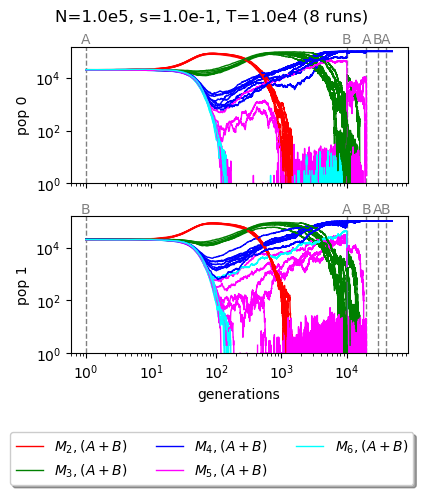

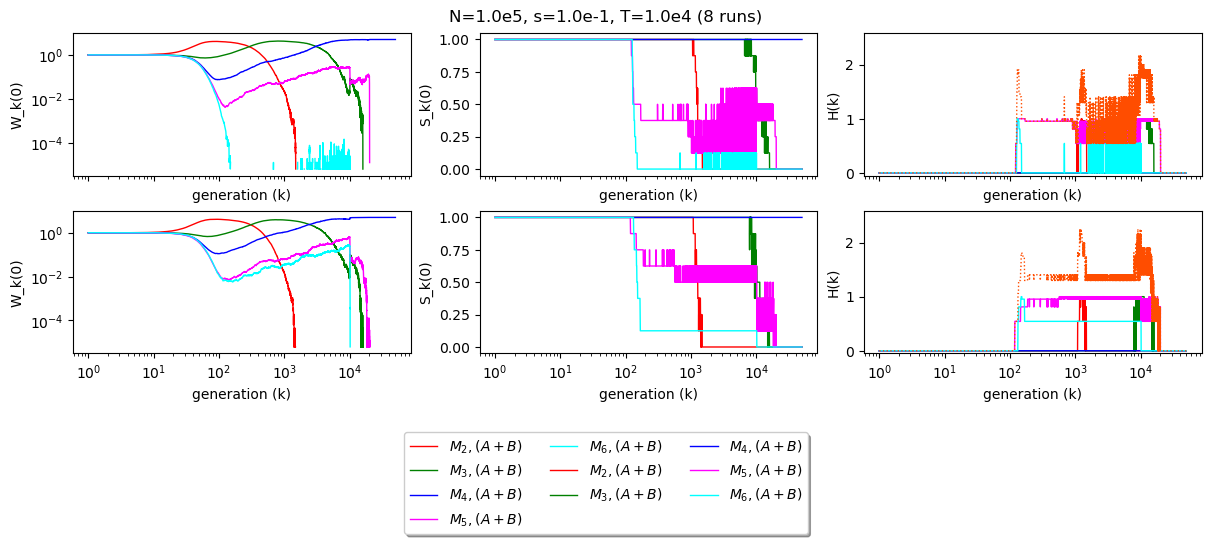

In [8]:
args = evosim.default_args.copy()
args.plotLog = False
args.s = 0.1
args.aToB = 0.0
args.minMu = 2
args.numClades = 5
args.plotAB = False
args.plotKFit = False
args.plotLog = True

###

args.numRuns = 8 # 8 - OK you can do numRuns=8 if you keep T=1e3

args.T = 1e4 # 1e4
args.numEpochs = 5 # 5
args.N = 1e5 # 1e4

###

args.numPops = 2 # 2 populations -> automatically switches to MIGRATION mode. There's NO mutation!
args.plotKFit = True # plot k-fitness, k-survivability

evosim.evosim(args)

---

### Stochastic environments – infinite pop

Infinite population size N (there is no drift)
sT:20.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Note: setting numRuns to 1 because N < 0 (infinite population)


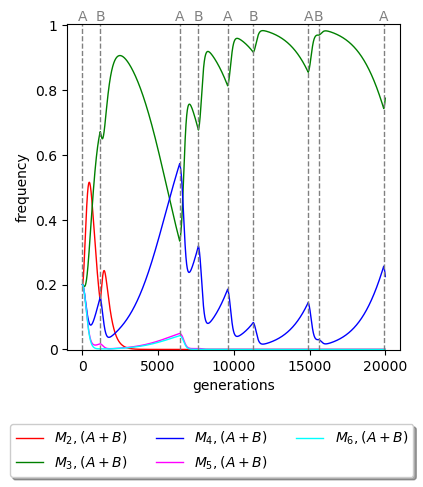

In [9]:
args = evosim.default_args.copy()
args.plotLog = False
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5
args.plotAB = False
args.plotLog = False
args.T = 2e3 # 2e3 epoch length
args.numEpochs = 10 # 10 multiple epochs

###

args.stochasticEnv = True

args.N = -1 # -1, change to 1e5
args.numRuns = 1 # 1, try 8

evosim.evosim(args)

### Stochastic environments – plotting k-fitness and k-survivability

Ns:1000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:20.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Using 8 processes for 8 runs.


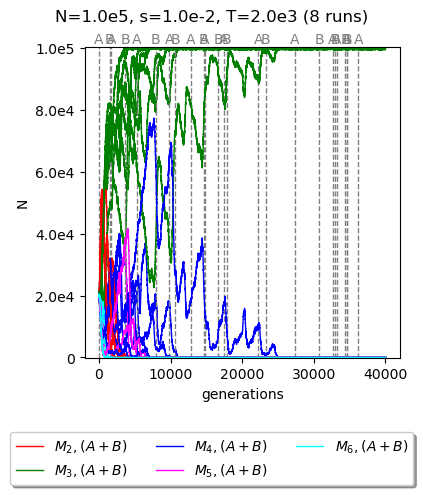

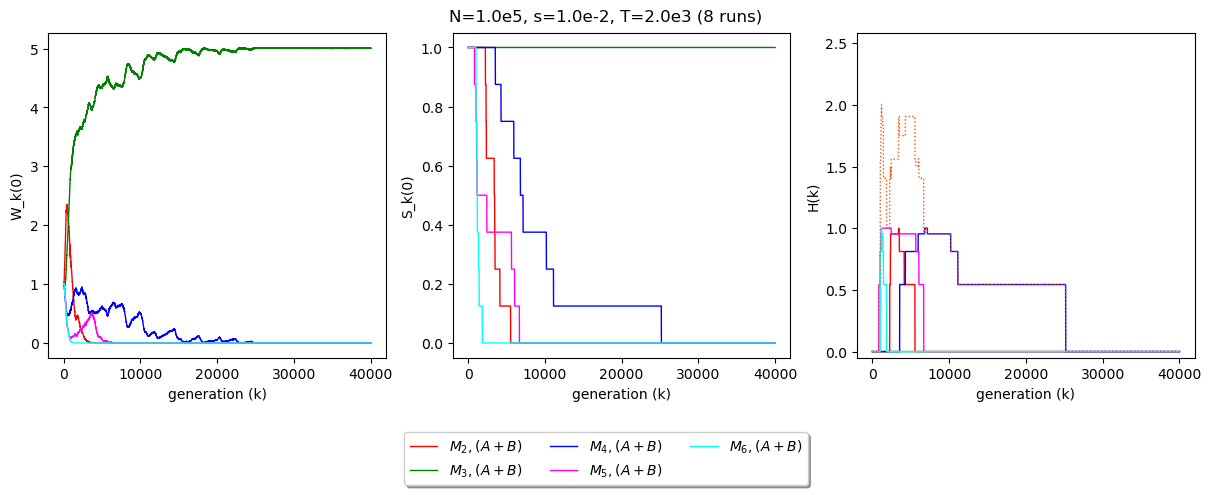

In [10]:
rgs = evosim.default_args.copy()
args.plotLog = False
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5
args.plotAB = False
args.plotLog = False
args.T = 2e3 # 2e3
args.numEpochs = 20 # 20

###

args.stochasticEnv = True
args.N = 1e5 # 1e5
args.numRuns = 8 # 8

args.plotKFit = True # True

evosim.evosim(args)